In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_min is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()

        train_data = self._process_data(data)
        labels = self._process_labels(label)

        train_data, labels = self._post_process(train_data, labels)

        nx = train_data.shape[1]
        ny = train_data.shape[0]

        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class),

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)

            # It is the responsibility of the child class to make sure that the label
            # is a boolean array, but we a chech here just in case.
            if label.dtype != 'bool':
                label = label.astype(bool)

            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels

        return label

    def _process_data(self, data):
        # normalization
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)

        if np.amax(data) != 0:
            data /= np.amax(data)

        return data

    def _post_process(self, data, labels):
        """
        Post processing hook that can be used for data augmentation
        :param data: the data array
        :param labels: the label array
        """
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]

        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))

        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels

        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

class RgbDataProvider(BaseDataProvider):
    channels = 3
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(RgbDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3


    def _next_data(self):
        data, label = create_image_and_label(self.nx, self.ny, **self.kwargs)
        return to_rgb(data), label

def create_image_and_label(nx,ny, cnt = 10, r_min = 5, r_max = 50, border = 92, sigma = 20, rectangles=False):


    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    for _ in range(cnt):
        a = np.random.randint(border, nx-border)
        b = np.random.randint(border, ny-border)
        r = np.random.randint(r_min, r_max)
        h = np.random.randint(1,255)

        y,x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)

        image[m] = h

    label[mask, 1] = 1

    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            a = np.random.randint(nx)
            b = np.random.randint(ny)
            r =  np.random.randint(r_min, r_max)
            h = np.random.randint(1,255)

            m = np.zeros((nx, ny), dtype=bool)
            m[a:a+r, b:b+r] = True
            mask = np.logical_or(mask, m)
            image[m] = h

        label[mask, 2] = 1

        label[..., 0] = ~(np.logical_or(label[...,1], label[...,2]))

    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)

    if rectangles:
        return image, label
    else:
        return image, label[..., 1]




def to_rgb(img):
    img = img.reshape(img.shape[0], img.shape[1])
    img[np.isnan(img)] = 0
    img -= np.amin(img)
    img /= np.amax(img)
    blue = np.clip(4*(0.75-img), 0, 1)
    red  = np.clip(4*(img-0.25), 0, 1)
    green= np.clip(44*np.fabs(img-0.5)-1., 0, 1)
    rgb = np.stack((red, green, blue), axis=2)
    return rgb


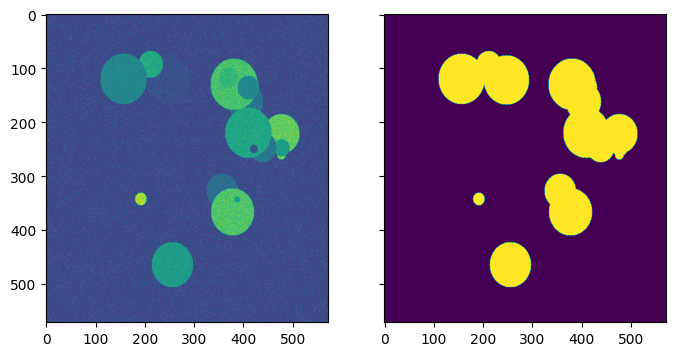

In [4]:
import matplotlib.pyplot as plt

nx = 572
ny = 572
generator = GrayScaleDataProvider(nx, ny, cnt=20)
x_test, y_test = generator(1)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
ax[0].imshow(x_test[0, ..., 0], aspect="auto")
ax[1].imshow(y_test[0, ..., 1], aspect="auto")

plt.show()

Генерация данных...
Train shape: (500, 128, 128, 1), (500, 128, 128, 2)
Val shape: (100, 128, 128, 1), (100, 128, 128, 2)
Test shape: (100, 128, 128, 1), (100, 128, 128, 2)
Data validation passed!


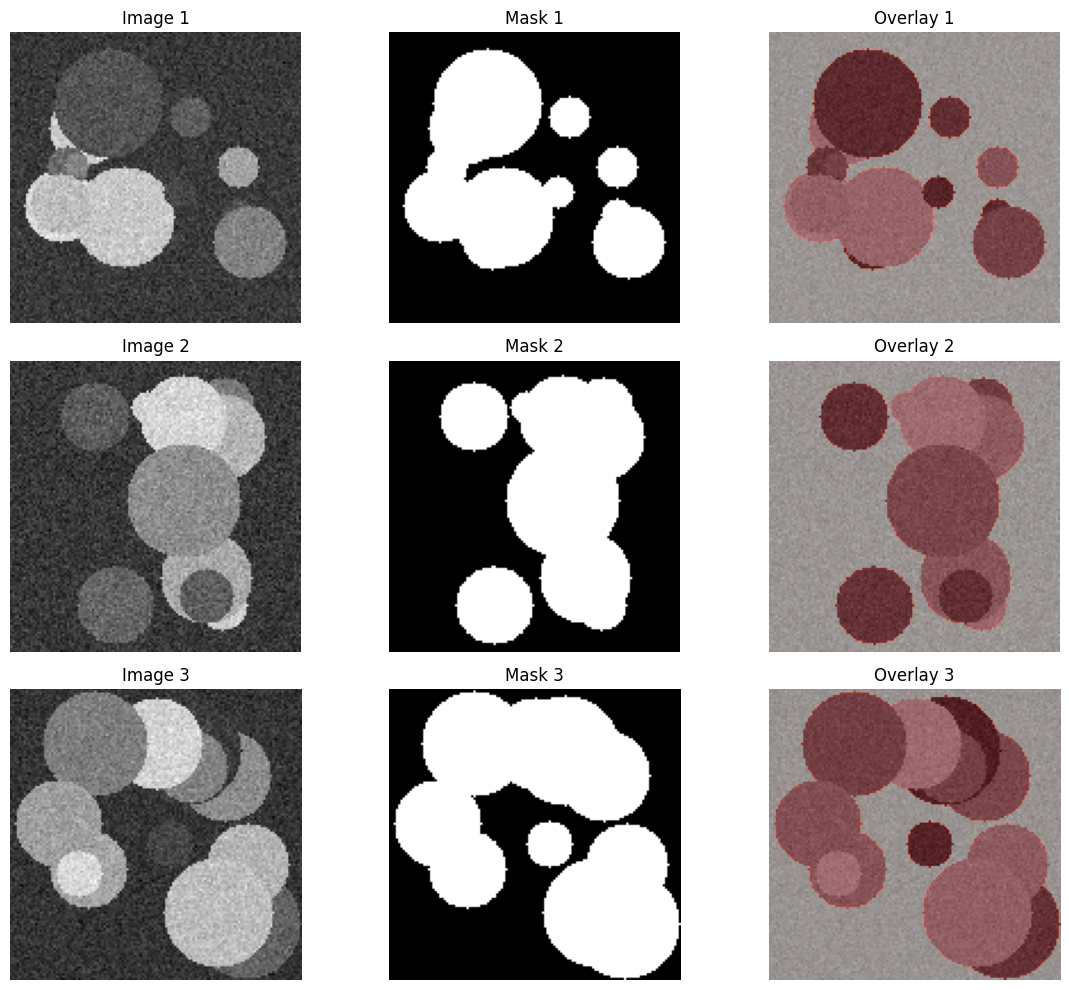

Using device: cpu
Начало обучения...


KeyboardInterrupt: 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Исправленная функция генерации изображений
def create_image_and_label(nx, ny, cnt=10, r_min=5, r_max=50, border=92, sigma=20, rectangles=False):
    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    
    # Адаптируем border к размеру изображения
    max_possible_border = min(nx, ny) // 2 - r_max
    actual_border = min(border, max_possible_border)
    
    if actual_border < 0:
        actual_border = 0
        r_max = min(nx, ny) // 2 - 1
    
    # Проверяем, что есть место для кругов
    if actual_border >= nx - actual_border or actual_border >= ny - actual_border:
        actual_border = 0
    
    for _ in range(cnt):
        # Проверяем, что есть валидный диапазон для размещения центра круга
        low_x = min(actual_border, nx - actual_border - 1)
        high_x = max(actual_border + 1, nx - actual_border)
        
        low_y = min(actual_border, ny - actual_border - 1)
        high_y = max(actual_border + 1, ny - actual_border)
        
        # Убеждаемся, что low < high
        if low_x >= high_x:
            low_x, high_x = 0, nx
        
        if low_y >= high_y:
            low_y, high_y = 0, ny
        
        a = np.random.randint(low_x, high_x)
        b = np.random.randint(low_y, high_y)
        
        # Адаптируем радиус
        max_r = min(a, nx-a, b, ny-b)
        actual_r_max = min(r_max, max_r)
        actual_r_min = min(r_min, actual_r_max)
        
        if actual_r_min < actual_r_max:
            r = np.random.randint(actual_r_min, max(actual_r_min + 1, actual_r_max))
        else:
            r = actual_r_min
        
        h = np.random.randint(1, 255)
        
        y, x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)
        image[m] = h

    label[mask, 1] = 1

    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            # Аналогичные проверки для прямоугольников
            if nx > r_min and ny > r_min:
                a = np.random.randint(0, max(1, nx - r_min))
                b = np.random.randint(0, max(1, ny - r_min))
                
                max_r_x = min(r_max, nx - a)
                max_r_y = min(r_max, ny - b)
                r = np.random.randint(r_min, max(r_min + 1, min(max_r_x, max_r_y)))
                
                h = np.random.randint(1, 255)
                
                m = np.zeros((nx, ny), dtype=bool)
                if a+r <= nx and b+r <= ny:
                    m[a:a+r, b:b+r] = True
                mask = np.logical_or(mask, m)
                image[m] = h
        
        label[mask, 2] = 1
        label[..., 0] = ~(np.logical_or(label[..., 1], label[..., 2]))

    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)

    if rectangles:
        return image, label
    else:
        return image, label[..., 1]

# Улучшенная версия GrayScaleDataProvider
class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_min is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()
        train_data = self._process_data(data)
        labels = self._process_labels(label)
        train_data, labels = self._post_process(train_data, labels)
        nx = train_data.shape[1]
        ny = train_data.shape[0]
        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class),

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)
            if label.dtype != 'bool':
                label = label.astype(bool)
            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels
        return label

    def _process_data(self, data):
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)
        if np.amax(data) != 0:
            data /= np.amax(data)
        return data

    def _post_process(self, data, labels):
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]
        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))
        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels
        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class = 3

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

# Функция для создания датасета с обработкой ошибок
def generate_dataset_safe(n_samples, nx=128, ny=128, cnt=15, **kwargs):
    """Безопасная генерация датасета с обработкой ошибок"""
    X_list = []
    Y_list = []
    
    # Адаптируем параметры для маленьких изображений
    adapted_kwargs = kwargs.copy()
    if 'border' in adapted_kwargs:
        adapted_kwargs['border'] = min(adapted_kwargs['border'], nx//2, ny//2)
    if 'r_max' in adapted_kwargs:
        adapted_kwargs['r_max'] = min(adapted_kwargs['r_max'], nx//2, ny//2)
    
    generator = GrayScaleDataProvider(nx, ny, cnt=cnt, **adapted_kwargs)
    
    for i in range(n_samples):
        try:
            X, Y = generator(1)
            X_list.append(X[0])
            Y_list.append(Y[0])
        except Exception as e:
            print(f"Warning: Failed to generate sample {i}: {e}")
            # Создаем пустое изображение с одним кругом
            X_safe, Y_safe = create_safe_image(nx, ny)
            X_list.append(X_safe)
            Y_list.append(Y_safe)
    
    return np.array(X_list), np.array(Y_list)

def create_safe_image(nx, ny):
    """Создает гарантированно рабочее изображение"""
    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    
    # Один гарантированный круг в центре
    r = min(nx, ny) // 4
    a, b = nx // 2, ny // 2
    y, x = np.ogrid[-a:nx-a, -b:ny-b]
    m = x*x + y*y <= r*r
    mask = np.logical_or(mask, m)
    image[m] = 128
    
    label[mask, 1] = 1
    
    image += np.random.normal(scale=10, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)
    
    # Преобразуем для соответствия формату
    X = image.reshape(1, ny, nx, 1)
    Y = np.zeros((1, ny, nx, 2))
    Y[0, ..., 1] = label[..., 1]
    Y[0, ..., 0] = ~label[..., 1]
    
    return X[0], Y[0]

# PyTorch Dataset (тот же)
class CircleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.FloatTensor(X).permute(0, 3, 1, 2)
        self.Y = torch.FloatTensor(Y).permute(0, 3, 1, 2)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# U-Net архитектура (та же)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=2):
        super(UNet, self).__init__()
        
        self.enc1 = DoubleConv(n_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.bridge = DoubleConv(512, 1024)
        
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        
        bridge = self.bridge(self.pool(enc4))
        
        up4 = self.up4(bridge)
        dec4 = self.dec4(torch.cat([up4, enc4], dim=1))
        
        up3 = self.up3(dec4)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
        
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
        
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))
        
        out = self.out_conv(dec1)
        return out

# Метрики
def calculate_iou(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = (pred + target).clamp(0, 1).sum(dim=(2, 3))
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean()

def calculate_dice(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    dice = (2. * intersection + 1e-6) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1e-6)
    return dice.mean()

def calculate_accuracy(pred, target):
    pred_class = pred.argmax(dim=1)
    target_class = target.argmax(dim=1)
    correct = (pred_class == target_class).float().sum()
    total = target_class.numel()
    return correct / total

# Функции обучения и валидации (те же)
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    train_iou = 0
    train_dice = 0
    train_acc = 0
    
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        
        # Для бинарной сегментации используем BCEWithLogitsLoss
        loss = criterion(output[:, 1:2], target[:, 1:2])
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        with torch.no_grad():
            probs = torch.sigmoid(output[:, 1:2])
            train_iou += calculate_iou(probs, target[:, 1:2]).item()
            train_dice += calculate_dice(probs, target[:, 1:2]).item()
            
            # Для accuracy нужно 2 канала
            pred_two_channel = torch.cat([1 - probs, probs], dim=1)
            train_acc += calculate_accuracy(pred_two_channel, target).item()
    
    n_batches = len(dataloader)
    return (total_loss / n_batches, train_iou / n_batches, 
            train_dice / n_batches, train_acc / n_batches)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    val_iou = 0
    val_dice = 0
    val_acc = 0
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output[:, 1:2], target[:, 1:2])
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(output[:, 1:2])
            val_iou += calculate_iou(probs, target[:, 1:2]).item()
            val_dice += calculate_dice(probs, target[:, 1:2]).item()
            
            pred_two_channel = torch.cat([1 - probs, probs], dim=1)
            val_acc += calculate_accuracy(pred_two_channel, target).item()
    
    n_batches = len(dataloader)
    return (total_loss / n_batches, val_iou / n_batches, 
            val_dice / n_batches, val_acc / n_batches)

# Параметры (уменьшенные для надежности)
NX, NY = 128, 128  # Размер изображений
N_TRAIN = 500      # Уменьшил для скорости
N_VAL = 100
N_TEST = 100
BATCH_SIZE = 8      # Уменьшил для стабильности
EPOCHS = 20
LEARNING_RATE = 1e-4

# Генерируем данные с безопасной функцией
print("Генерация данных...")
X_train, Y_train = generate_dataset_safe(N_TRAIN, nx=NX, ny=NY, cnt=15, border=20, r_max=30)
X_val, Y_val = generate_dataset_safe(N_VAL, nx=NX, ny=NY, cnt=15, border=20, r_max=30)
X_test, Y_test = generate_dataset_safe(N_TEST, nx=NX, ny=NY, cnt=15, border=20, r_max=30)

print(f"Train shape: {X_train.shape}, {Y_train.shape}")
print(f"Val shape: {X_val.shape}, {Y_val.shape}")
print(f"Test shape: {X_test.shape}, {Y_test.shape}")

# Проверяем данные на валидность
assert not np.isnan(X_train).any(), "NaN values in training data!"
assert not np.isinf(X_train).any(), "Inf values in training data!"
print("Data validation passed!")

# Визуализация примеров
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i in range(3):
    axes[i, 0].imshow(X_train[i, :, :, 0], cmap='gray')
    axes[i, 0].set_title(f'Image {i+1}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(Y_train[i, :, :, 1], cmap='gray')
    axes[i, 1].set_title(f'Mask {i+1}')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(X_train[i, :, :, 0], cmap='gray')
    axes[i, 2].imshow(Y_train[i, :, :, 1], alpha=0.5, cmap='Reds')
    axes[i, 2].set_title(f'Overlay {i+1}')
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

# Создаем датасеты и загрузчики
train_dataset = CircleDataset(X_train, Y_train)
val_dataset = CircleDataset(X_val, Y_val)
test_dataset = CircleDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Инициализация модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet(n_channels=1, n_classes=2).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# История обучения
history = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_acc': [], 'val_acc': []
}

# Обучение
print("Начало обучения...")
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss, train_iou, train_dice, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_iou, val_dice, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'unet_best.pth')
    
    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train IoU: {train_iou:.4f}, Val IoU: {val_iou:.4f}, "
          f"Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}")

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history['train_iou'], label='Train IoU')
axes[0, 1].plot(history['val_iou'], label='Val IoU')
axes[0, 1].set_title('IoU (Intersection over Union)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(history['train_dice'], label='Train Dice')
axes[1, 0].plot(history['val_dice'], label='Val Dice')
axes[1, 0].set_title('Dice Coefficient')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(history['train_acc'], label='Train Accuracy')
axes[1, 1].plot(history['val_acc'], label='Val Accuracy')
axes[1, 1].set_title('Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Оценка на тестовой выборке
print("\nОценка на тестовой выборке:")
test_loss, test_iou, test_dice, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Визуализация предсказаний
print("\nВизуализация предсказаний...")
model.eval()
with torch.no_grad():
    test_images, test_masks = next(iter(test_loader))
    test_images = test_images[:5].to(device)
    
    outputs = model(test_images)
    predictions = torch.sigmoid(outputs[:, 1:2])
    
    test_images = test_images.cpu().permute(0, 2, 3, 1)
    test_masks = test_masks.cpu().permute(0, 2, 3, 1)
    predictions = predictions.cpu().permute(0, 2, 3, 1)

fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for i in range(5):
    axes[i, 0].imshow(test_images[i, :, :, 0], cmap='gray')
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(test_masks[i, :, :, 1], cmap='gray')
    axes[i, 1].set_title('True Mask')
    axes[i, 1].axis('off')
    
    pred_mask = predictions[i, :, :, 0]
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(test_images[i, :, :, 0], cmap='gray')
    axes[i, 3].imshow(pred_mask > 0.5, alpha=0.5, cmap='Reds')
    axes[i, 3].set_title('Overlay')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

print("\nОбучение завершено успешно!")

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead, SSDRegressionHead
import torchvision.transforms.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import glob
import random
import time
from collections import defaultdict
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import platform
import warnings
warnings.filterwarnings('ignore')

# Настройки для Windows
if platform.system() == 'Windows':
    import torch.multiprocessing
    torch.multiprocessing.freeze_support()

# Версии библиотек
print("=" * 50)
print("ИНФОРМАЦИЯ О СИСТЕМЕ")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Python version: {platform.python_version()}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Для CPU оптимизация
if device.type == 'cpu':
    # Установите число потоков под ваш процессор
    # Для Intel i5/i7 обычно 4-8 потоков
    torch.set_num_threads(4)
    print(f"CPU threads: {torch.get_num_threads()}")

ИНФОРМАЦИЯ О СИСТЕМЕ
PyTorch version: 2.0.1+cpu
Torchvision version: 0.15.2+cpu
Python version: 3.11.0
Platform: Windows 10
CUDA available: False
Using device: cpu
CPU threads: 4


In [10]:
# Константы классов (BCCD)
CLASSES = {
    1: 'RBC',        # Эритроциты
    2: 'WBC',        # Лейкоциты
    3: 'Platelets'   # Тромбоциты
}
NUM_CLASSES = len(CLASSES) + 1  # +1 для фона (класс 0)
CLASS_NAMES = {v: k for k, v in CLASSES.items()}  # Обратный маппинг

# Пути к данным (ИЗМЕНИТЕ ПОД СВОИ!)
ANNOTATIONS_DIR = "D:/data science/Homework/modul7/Annotations"
IMAGES_DIR = "D:/data science/Homework/modul7/JPEGImages"

# Параметры модели и обучения
IMAGE_SIZE = 300  # SSD300
BATCH_SIZE = 2     # Маленький батч для CPU
NUM_EPOCHS = 15    # Начните с 15 эпох
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
NUM_WORKERS = 0    # 0 для Windows!

# Проверка путей
print("=" * 50)
print("ПРОВЕРКА ПУТЕЙ")
print("=" * 50)
print(f"Annotations dir: {ANNOTATIONS_DIR}")
print(f"Images dir: {IMAGES_DIR}")
print(f"Annotations exists: {os.path.exists(ANNOTATIONS_DIR)}")
print(f"Images exists: {os.path.exists(IMAGES_DIR)}")

ПРОВЕРКА ПУТЕЙ
Annotations dir: D:/data science/Homework/modul7/Annotations
Images dir: D:/data science/Homework/modul7/JPEGImages
Annotations exists: True
Images exists: True


In [11]:
class BCCDDataset(Dataset):
    """Датасет для Blood Cell Count Detection (BCCD)"""
    
    def __init__(self, xml_paths, img_dir, image_size=300):
        self.xml_paths = xml_paths
        self.img_dir = img_dir
        self.image_size = image_size
        
    def __len__(self):
        return len(self.xml_paths)
    
    def __getitem__(self, idx):
        xml_path = self.xml_paths[idx]
        
        # Парсим XML
        image_name, boxes, labels, orig_size = self._parse_xml(xml_path)
        
        # Загружаем изображение
        img_path = os.path.join(self.img_dir, image_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Ошибка загрузки {img_path}: {e}")
            # Возвращаем пустое изображение
            image = Image.new('RGB', (self.image_size, self.image_size))
        
        orig_width, orig_height = orig_size
        
        # Масштабируем изображение
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        
        # Масштабируем bounding boxes
        scale_x = self.image_size / orig_width
        scale_y = self.image_size / orig_height
        
        scaled_boxes = []
        for box in boxes:
            xmin, ymin, xmax, ymax = box
            scaled_boxes.append([
                max(0, xmin * scale_x),
                max(0, ymin * scale_y),
                min(self.image_size, xmax * scale_x),
                min(self.image_size, ymax * scale_y)
            ])
        
        # Преобразуем в тензоры
        if len(scaled_boxes) > 0:
            boxes_tensor = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_tensor = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
        
        # Формируем target
        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor,
            'image_id': torch.tensor([idx]),
            'area': (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * 
                    (boxes_tensor[:, 2] - boxes_tensor[:, 0]) if len(boxes_tensor) > 0 
                    else torch.zeros(0),
            'iscrowd': torch.zeros((len(boxes_tensor),), dtype=torch.int64)
        }
        
        # Преобразуем изображение в тензор
        image_tensor = F.to_tensor(image)
        
        return image_tensor, target
    
    def _parse_xml(self, xml_path):
        """Парсинг XML в формате Pascal VOC"""
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Имя файла
        image_name = root.find('filename').text
        
        # Размеры оригинального изображения
        size = root.find('size')
        width = int(size.find('width').text)
        height = int(size.find('height').text)
        
        boxes = []
        labels = []
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            
            # Пропускаем неизвестные классы
            if name not in CLASS_NAMES:
                continue
            
            bbox = obj.find('bndbox')
            xmin = int(float(bbox.find('xmin').text))
            ymin = int(float(bbox.find('ymin').text))
            xmax = int(float(bbox.find('xmax').text))
            ymax = int(float(bbox.find('ymax').text))
            
            # Валидация координат
            if xmin < xmax and ymin < ymax and xmin >= 0 and ymin >= 0:
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(CLASS_NAMES[name])  # 1, 2 или 3
        
        return image_name, boxes, labels, (width, height)


print("✓ Класс BCCDDataset создан")

✓ Класс BCCDDataset создан


In [12]:
# ============================================
# БЛОК 4: Создание модели SSD
# ============================================

def create_ssd_model(num_classes, pretrained_backbone=True):
    """
    Создает модель SSD300 с VGG16 backbone
    """
    print("Создание модели SSD300...")
    
    model = ssd300_vgg16(
        weights=None,  # Не используем веса COCO
        weights_backbone=torchvision.models.VGG16_Weights.IMAGENET1K_V1 if pretrained_backbone else None,
        num_classes=num_classes
    )
    
    return model


# Создаем модель
model = create_ssd_model(NUM_CLASSES, pretrained_backbone=True)
model.to(device)

# Информация о модели
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Модель создана")
print(f"  Всего параметров: {total_params:,}")
print(f"  Обучаемых параметров: {trainable_params:,}")
print(f"  Количество классов: {NUM_CLASSES} (включая фон)")

Создание модели SSD300...
✓ Модель создана
  Всего параметров: 24,013,232
  Обучаемых параметров: 23,974,512
  Количество классов: 4 (включая фон)


In [13]:
# ============================================
# БЛОК 5: Загрузка данных
# ============================================

print("=" * 50)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 50)

# Собираем все XML файлы
xml_files = sorted(glob.glob(os.path.join(ANNOTATIONS_DIR, "*.xml")))
print(f"Найдено XML файлов: {len(xml_files)}")

if len(xml_files) == 0:
    raise FileNotFoundError(f"Не найдены XML файлы в {ANNOTATIONS_DIR}")

# Покажем пример одного XML для проверки
sample_xml = xml_files[0]
tree = ET.parse(sample_xml)
root = tree.getroot()
print(f"Пример: {root.find('filename').text}")
print(f"Классы в файле: {[obj.find('name').text for obj in root.findall('object')]}")

# Разделение на train/val (80/20)
train_xml, val_xml = train_test_split(
    xml_files, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"\nTrain: {len(train_xml)} файлов")
print(f"Val: {len(val_xml)} файлов")

# Создаем датасеты
print("\nСоздание датасетов...")
train_dataset = BCCDDataset(train_xml, IMAGES_DIR, image_size=IMAGE_SIZE)
val_dataset = BCCDDataset(val_xml, IMAGES_DIR, image_size=IMAGE_SIZE)

# Функция для объединения батчей
def collate_fn(batch):
    return tuple(zip(*batch))

# Создаем DataLoader'ы
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

print(f"✓ Train batches: {len(train_loader)}")
print(f"✓ Val batches: {len(val_loader)}")

# Проверяем один батч
print("\nПроверка загрузки...")
try:
    images, targets = next(iter(train_loader))
    print(f"  Batch size: {len(images)}")
    print(f"  Image shape: {images[0].shape}")
    print(f"  Target keys: {list(targets[0].keys())}")
    print(f"  Boxes shape: {targets[0]['boxes'].shape}")
    print(f"  Labels: {targets[0]['labels']}")
    print("✓ DataLoader работает корректно!")
except Exception as e:
    print(f"❌ Ошибка: {e}")

ЗАГРУЗКА ДАННЫХ
Найдено XML файлов: 364
Пример: BloodImage_00000.jpg
Классы в файле: ['WBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC', 'RBC']

Train: 291 файлов
Val: 73 файлов

Создание датасетов...
✓ Train batches: 146
✓ Val batches: 73

Проверка загрузки...
  Batch size: 2
  Image shape: torch.Size([3, 300, 300])
  Target keys: ['boxes', 'labels', 'image_id', 'area', 'iscrowd']
  Boxes shape: torch.Size([12, 4])
  Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2])
✓ DataLoader работает корректно!


In [21]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10):
    """Обучение одной эпохи"""
    model.train()
    total_loss = 0
    loss_components = defaultdict(float)
    start_time = time.time()
    valid_batches = 0
    
    for i, (images, targets) in enumerate(data_loader):
        try:
            # Перемещаем на устройство
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Прямой проход
            loss_dict = model(images, targets)
            
            # Суммируем потери
            if isinstance(loss_dict, dict):
                losses = sum(loss for loss in loss_dict.values())
            else:
                losses = loss_dict
            
            # Проверка на NaN
            if torch.isnan(losses) or torch.isinf(losses):
                print(f"  ⚠ Batch {i+1}: NaN/Inf detected, skipping...")
                continue
            
            # Обратный проход
            optimizer.zero_grad()
            losses.backward()
            
            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Логирование
            total_loss += losses.item()
            valid_batches += 1
            
            if isinstance(loss_dict, dict):
                for k, v in loss_dict.items():
                    if not torch.isnan(v) and not torch.isinf(v):
                        loss_components[k] += v.item()
            
            if (i + 1) % print_freq == 0:
                elapsed = time.time() - start_time
                print(f"  Batch [{i+1}/{len(data_loader)}] "
                      f"Loss: {losses.item():.4f} "
                      f"Time: {elapsed:.1f}s")
        
        except Exception as e:
            print(f"  ⚠ Ошибка в batch {i+1}: {str(e)[:100]}")
            continue
    
    # Средние потери (только по валидным батчам)
    if valid_batches == 0:
        print("  ❌ Все батчи пропущены! Проблема с данными или моделью.")
        return 0.0, {}
    
    avg_loss = total_loss / valid_batches
    avg_components = {k: v / valid_batches for k, v in loss_components.items()}
    
    return avg_loss, avg_components


@torch.no_grad()
def validate(model, data_loader, device):
    """Валидация модели"""
    model.eval()
    total_loss = 0
    loss_components = defaultdict(float)
    valid_batches = 0
    
    for images, targets in data_loader:
        try:
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            
            if isinstance(loss_dict, dict):
                losses = sum(loss for loss in loss_dict.values())
            else:
                losses = loss_dict
            
            if torch.isnan(losses) or torch.isinf(losses):
                continue
            
            total_loss += losses.item()
            valid_batches += 1
            
            if isinstance(loss_dict, dict):
                for k, v in loss_dict.items():
                    if not torch.isnan(v) and not torch.isinf(v):
                        loss_components[k] += v.item()
        
        except Exception as e:
            print(f"  ⚠ Ошибка валидации: {str(e)[:100]}")
            continue
    
    if valid_batches == 0:
        return 0.0, {}
    
    avg_loss = total_loss / valid_batches
    avg_components = {k: v / valid_batches for k, v in loss_components.items()}
    
    return avg_loss, avg_components


print("✓ Функции обучения созданы (с защитой от NaN)")

✓ Функции обучения созданы (с защитой от NaN)


In [30]:

@torch.no_grad()
def validate_simple(model, data_loader, device):
    """Максимально простая валидация"""
    # Держим модель в train режиме для получения loss
    model.train()
    
    total_loss = 0
    count = 0
    
    for images, targets in data_loader:
        try:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Получаем потери (передаем targets)
            output = model(images, targets)
            
            # Проверяем тип выхода
            if isinstance(output, dict):
                # Это loss_dict
                loss = sum(v for v in output.values())
            elif isinstance(output, list):
                # Это предсказания - значит модель в eval режиме
                continue
            else:
                continue
            
            if not torch.isnan(loss) and not torch.isinf(loss):
                total_loss += loss.item()
                count += 1
                
        except Exception as e:
            continue
    
    if count == 0:
        return float('inf')
    
    return total_loss / count


def train_one_epoch_simple(model, optimizer, data_loader, device, epoch, print_freq=10):
    """Простая функция обучения одной эпохи"""
    model.train()
    total_loss = 0
    total_class_loss = 0
    total_bbox_loss = 0
    valid_batches = 0
    start_time = time.time()
    
    for i, (images, targets) in enumerate(data_loader):
        try:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            
            # Проверяем что это словарь с потерями
            if not isinstance(loss_dict, dict):
                continue
            
            losses = sum(v for v in loss_dict.values())
            
            if torch.isnan(losses) or torch.isinf(losses):
                continue
            
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimizer.step()
            
            total_loss += losses.item()
            if 'classification' in loss_dict:
                total_class_loss += loss_dict['classification'].item()
            if 'bbox_regression' in loss_dict:
                total_bbox_loss += loss_dict['bbox_regression'].item()
            valid_batches += 1
            
            if (i + 1) % print_freq == 0:
                elapsed = time.time() - start_time
                print(f"  Batch [{i+1}/{len(data_loader)}] "
                      f"Loss: {losses.item():.4f} | "
                      f"cls: {loss_dict.get('classification', 0):.2f} | "
                      f"bbox: {loss_dict.get('bbox_regression', 0):.2f} | "
                      f"Time: {elapsed:.1f}s")
        
        except Exception as e:
            print(f"  ⚠ Batch {i+1} error: {str(e)[:80]}")
            continue
    
    if valid_batches == 0:
        return 0, 0, 0
    
    avg_loss = total_loss / valid_batches
    avg_class = total_class_loss / valid_batches
    avg_bbox = total_bbox_loss / valid_batches
    
    return avg_loss, avg_class, avg_bbox


print("✓ Функции определены: validate_simple, train_one_epoch_simple")

✓ Функции определены: validate_simple, train_one_epoch_simple


In [31]:

print("=" * 50)
print("ПРОВЕРКА ВАЛИДАЦИИ")
print("=" * 50)

val_loss = validate_simple(model, val_loader, device)
print(f"Val Loss: {val_loss:.4f}")

if val_loss == float('inf'):
    print("❌ Валидация не работает! Давайте проверим детальнее...")
    
    # Проверим один батч вручную
    model.train()
    test_images, test_targets = next(iter(val_loader))
    test_images = [img.to(device) for img in test_images]
    test_targets = [{k: v.to(device) for k, v in t.items()} for t in test_targets]
    
    output = model(test_images, test_targets)
    print(f"Тип выхода: {type(output)}")
    
    if isinstance(output, dict):
        print(f"Ключи: {list(output.keys())}")
        loss = sum(v for v in output.values())
        print(f"Loss: {loss.item():.4f}")
    elif isinstance(output, list):
        print(f"Модель вернула предсказания (список из {len(output)} элементов)")
        print(f"Ключи первого элемента: {output[0].keys()}")
else:
    print("✓ Валидация работает!")

ПРОВЕРКА ВАЛИДАЦИИ
Val Loss: 4.8939
✓ Валидация работает!


НАЧАЛО ОБУЧЕНИЯ
Продолжаем с эпохи 36
Эпох всего: 20
Train batches: 146
Val batches: 73
--------------------------------------------------

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Завершено эпох: 35
Лучший val loss: 4.4343
Модель: best_model_bccd.pth


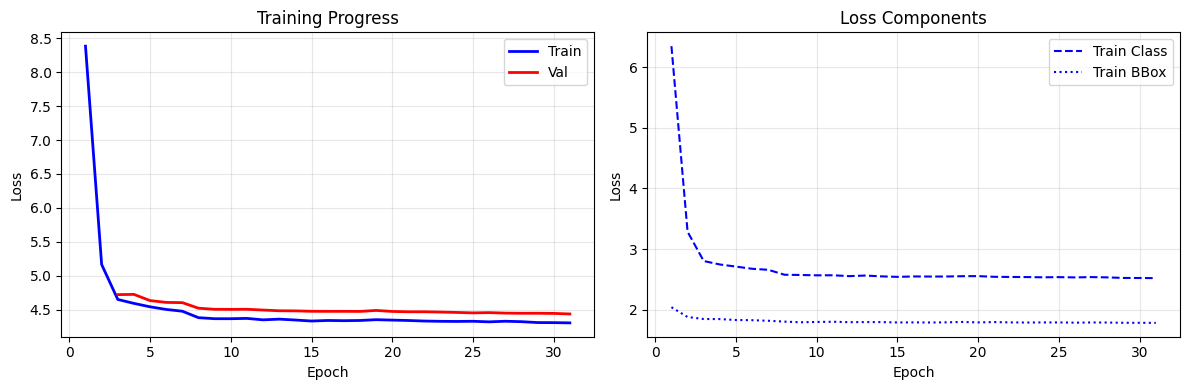

In [38]:

print("=" * 50)
print("НАЧАЛО ОБУЧЕНИЯ")
print("=" * 50)

# Параметры
LEARNING_RATE = 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
GRAD_CLIP = 1.0
NUM_EPOCHS = 20

# Оптимизатор (если ещё не создан)
if 'optimizer' not in dir():
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    print("Оптимизатор создан заново")

# История (если ещё не создана)
if 'history' not in dir():
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_class_loss': [],
        'train_bbox_loss': []
    }
    print("История создана заново")

# Определяем начальную эпоху
if 'epoch' in dir() and epoch > 0:
    start_epoch = epoch + 1
    print(f"Продолжаем с эпохи {start_epoch}")
else:
    start_epoch = 1
    best_val_loss = float('inf')
    print("Начинаем с эпохи 1")

print(f"Эпох всего: {NUM_EPOCHS}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print("-" * 50)

patience = 10
no_improve = 0

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # ========================================
    # TRAINING
    # ========================================
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("Training...")
    
    avg_train_loss, avg_train_class, avg_train_bbox = train_one_epoch_simple(
        model, optimizer, train_loader, device, epoch, print_freq=10
    )
    
    # ========================================
    # VALIDATION
    # ========================================
    print("Validation...")
    avg_val_loss = validate_simple(model, val_loader, device)
    
    # ========================================
    # ОБНОВЛЕНИЕ И ВЫВОД
    # ========================================
    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Сохраняем историю
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss if avg_val_loss != float('inf') else 0)
    history['train_class_loss'].append(avg_train_class)
    history['train_bbox_loss'].append(avg_train_bbox)
    
    epoch_time = time.time() - epoch_start
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{NUM_EPOCHS} - {epoch_time/60:.2f} min")
    print(f"  Train Loss:  {avg_train_loss:.4f}")
    print(f"  Train Class: {avg_train_class:.4f}")
    print(f"  Train BBox:  {avg_train_bbox:.4f}")
    
    if avg_val_loss != float('inf'):
        print(f"  Val Loss:    {avg_val_loss:.4f}")
    else:
        print(f"  Val Loss:    ❌ INF")
    
    print(f"  LR:          {current_lr:.6f}")
    
    # Сохраняем лучшую модель
    if avg_val_loss < best_val_loss and avg_val_loss > 0 and avg_val_loss != float('inf'):
        improvement = best_val_loss - avg_val_loss
        best_val_loss = avg_val_loss
        no_improve = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'train_loss': avg_train_loss,
            'classes': CLASSES,
            'history': history,
        }, 'best_model_bccd.pth')
        print(f"  ✓ Лучшая модель сохранена! (val_loss: {avg_val_loss:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement: {no_improve} epochs")
    
    # Чекпоинт каждые 5 эпох
    if epoch % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
        }, f'checkpoint_epoch_{epoch}.pth')
        print(f"  ✓ Чекпоинт: checkpoint_epoch_{epoch}.pth")
    
    # Early stopping
    if no_improve >= patience:
        print(f"\n  ⏹ Early stopping после {patience} эпох без улучшения")
        break
    
    print(f"{'='*50}")

# ========================================
# ФИНАЛ
# ========================================
print("\n" + "=" * 60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=" * 60)
print(f"Завершено эпох: {epoch}")
print(f"Лучший val loss: {best_val_loss:.4f}")
print(f"Модель: best_model_bccd.pth")

# График
if len(history['train_loss']) > 0:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
    plt.plot(epochs_range, history['val_loss'], 'r-', label='Val', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_class_loss'], 'b--', label='Train Class')
    plt.plot(epochs_range, history['train_bbox_loss'], 'b:', label='Train BBox')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [42]:
print("=" * 50)
print("ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ (Learning Rate снижен)")
print("=" * 50)

# Уменьшаем learning rate в 10 раз
for param_group in optimizer.param_groups:
    param_group['lr'] = 0.0001  # Было 0.001
    
print(f"Новый Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

# Добавим ещё 15 эпох
additional_epochs = 15
start_epoch = epoch + 1
end_epoch = epoch + additional_epochs

print(f"Эпохи: {start_epoch} - {end_epoch}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print("-" * 50)

# Сбрасываем early stopping
no_improve = 0
# best_val_loss пока оставляем

for epoch in range(start_epoch, end_epoch + 1):
    epoch_start = time.time()
    

    print(f"\nEpoch {epoch}/{end_epoch}")
    print("Training...")
    
    avg_train_loss, avg_train_class, avg_train_bbox = train_one_epoch_simple(
        model, optimizer, train_loader, device, epoch, print_freq=20  # Реже вывод
    )
    
    
    print("Validation...")
    avg_val_loss = validate_simple(model, val_loader, device)
    
   
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss if avg_val_loss != float('inf') else 0)
    history['train_class_loss'].append(avg_train_class)
    history['train_bbox_loss'].append(avg_train_bbox)
    
    epoch_time = time.time() - epoch_start
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{end_epoch} - {epoch_time/60:.2f} min")
    print(f"  Train Loss:  {avg_train_loss:.4f}")
    print(f"  Train Class: {avg_train_class:.4f}")
    print(f"  Train BBox:  {avg_train_bbox:.4f}")
    
    if avg_val_loss != float('inf'):
        print(f"  Val Loss:    {avg_val_loss:.4f}")
    else:
        print(f"  Val Loss:    ❌ INF")
    
    print(f"  LR:          {current_lr:.6f}")
    
    # Сохраняем лучшую модель
    if avg_val_loss < best_val_loss and avg_val_loss > 0 and avg_val_loss != float('inf'):
        improvement = best_val_loss - avg_val_loss
        best_val_loss = avg_val_loss
        no_improve = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'train_loss': avg_train_loss,
            'classes': CLASSES,
            'history': history,
        }, 'best_model_bccd.pth')
        print(f"  ✓ Лучшая модель! (val_loss: {avg_val_loss:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement: {no_improve} epochs")
    
    # Чекпоинт каждые 5 эпох
    if epoch % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'history': history,
        }, f'checkpoint_epoch_{epoch}.pth')
    
    # Early stopping
    if no_improve >= 10:
        print(f"\n  ⏹ Early stopping после 10 эпох без улучшения")
        break
    
    print(f"{'='*50}")

print("\n✓ Обучение завершено!")
print(f"Лучший val loss: {best_val_loss:.4f}")

ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ (Learning Rate снижен)
Новый Learning Rate: 0.000100
Эпохи: 51 - 65
Train batches: 146
Val batches: 73
--------------------------------------------------

Epoch 51/65
Training...
  Batch [20/146] Loss: 4.9084 | cls: 2.87 | bbox: 2.04 | Time: 54.2s
  Batch [40/146] Loss: 4.2838 | cls: 2.49 | bbox: 1.80 | Time: 107.1s
  Batch [60/146] Loss: 4.0247 | cls: 2.39 | bbox: 1.63 | Time: 159.2s
  Batch [80/146] Loss: 4.2013 | cls: 2.50 | bbox: 1.70 | Time: 216.1s
  Batch [100/146] Loss: 4.0649 | cls: 2.37 | bbox: 1.69 | Time: 288.7s
  Batch [120/146] Loss: 4.3525 | cls: 2.49 | bbox: 1.86 | Time: 361.3s
  Batch [140/146] Loss: 4.1830 | cls: 2.43 | bbox: 1.76 | Time: 425.7s
Validation...

Epoch 51/65 - 8.04 min
  Train Loss:  4.5204
  Train Class: 2.6606
  Train BBox:  1.8598
  Val Loss:    4.2924
  LR:          0.000100
  ✓ Лучшая модель! (val_loss: 4.2924)

Epoch 52/65
Training...
  Batch [20/146] Loss: 3.9672 | cls: 2.28 | bbox: 1.69 | Time: 57.3s
  Batch [40/146] Loss: 4.0

In [41]:
print("=" * 50)
print("ПЕРЕКЛЮЧАЕМСЯ НА ADAM OPTIMIZER")
print("=" * 50)

# Создаем новый оптимизатор
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0001,
    weight_decay=0.0005
)

lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Оптимизатор: Adam")
print(f"Learning rate: 0.0001")
print("Готово к продолжению обучения")

# Сбрасываем счетчики
no_improve = 0
start_epoch = epoch + 1
end_epoch = start_epoch + 20

print(f"\nМожно запустить цикл обучения снова (эпохи {start_epoch}-{end_epoch})")

ПЕРЕКЛЮЧАЕМСЯ НА ADAM OPTIMIZER
Оптимизатор: Adam
Learning rate: 0.0001
Готово к продолжению обучения

Можно запустить цикл обучения снова (эпохи 51-71)
